# Coding Exercises (Part 5)

Now, you will have the opportunity to practice what you have learned. <br>
__Follow the instructions__ and insert your code! 

The correct answer is provided below your coding cell. There you can check whether your code is correct.

If you need some help or if you want to check your code, you can also have a look at the __solutions__.

### Have Fun!

--------------------------------------------------------------------------------------------------------------

## Exercise 1: Correlation & Regression

In the following you are going to analyze the relationship between __budget and revenue__ for movies released between __Jan-01-2000__ and __Dec-31-2009__.

In [1]:
#run the cell!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

In [4]:
#run the cell!
df = pd.read_csv("bud_vs_rev.csv", parse_dates = ["release_date"], index_col = "release_date")
df

,title,budget,revenue
release_date,,,
1915-02-08,The Birth of a Nation,0.100000,11.000000
1915-12-13,The Cheat,0.017311,0.137365
1916-12-24,"20,000 Leagues Under the Sea",0.200000,8.000000
1918-08-01,Mickey,0.250000,8.000000
1921-01-21,The Kid,0.250000,2.500000
...,...,...,...
2017-07-26,Atomic Blonde,30.000000,90.007945
2017-07-28,The Emoji Movie,50.000000,66.913939
2017-08-03,The Dark Tower,60.000000,71.000000


1. Select the ten-year period from __Jan-01-2000__ until __Dec-31-2009__ and __overwrite df__.   

In [5]:
df = df.loc["2000-01-01":"2009-12-31"]
df

,title,budget,revenue
release_date,,,
2000-01-12,Next Friday,11.0,59.827328
2000-01-14,Supernova,90.0,14.828081
2000-01-24,Saving Grace,10.0,26.330482
2000-01-28,Isn't She Great,36.0,3.003296
2000-02-01,The Broken Hearts Club: A Romantic Comedy,1.0,1.744858
...,...,...,...
2009-12-23,Sherlock Holmes,90.0,524.028679
2009-12-23,It's Complicated,85.0,219.103655
2009-12-23,3 Idiots,9.0,70.000000


In [6]:
#run the cell!
df.info(memory_usage = "deep" , show_counts = True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1780 entries, 2000-01-12 to 2009-12-31
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   title    1780 non-null   object 
 1   budget   1780 non-null   float64
 2   revenue  1780 non-null   float64
dtypes: float64(2), object(1)
memory usage: 153.3 KB


In [8]:
#run the cell!
df.describe(include = "number")

,budget,revenue
count,1780.000000,1780.000000
mean,37.194656,94.618574
std,40.165906,162.214866
min,0.000001,0.000002
25%,9.000000,9.975529
50%,25.000000,38.554792
75%,50.000000,108.649821
max,300.000000,2787.965087


In [10]:
df["title"].value_counts(ascending = False , dropna = False)

title
Wanted                             2
Pokémon: Spell of the Unknown      2
Clockstoppers                      2
Confessions of a Dangerous Mind    2
Once                               1
                                  ..
Miracle                            1
Catch That Kid                     1
The Big Bounce                     1
RRRrrrr!!!                         1
Black Lightning                    1
Name: count, Length: 1776, dtype: int64

2. Calculate __average/mean__ budget and revenue.

In [12]:
df.select_dtypes(include = "number").mean()

budget     37.194656
revenue    94.618574
dtype: float64

3. Return the __10 most expensive__ movies. 

In [18]:
df["budget"].nlargest(n = 10)

release_date
2007-05-19    300.0
2006-06-28    270.0
2007-05-01    258.0
2009-07-07    250.0
2009-12-10    237.0
2008-05-15    225.0
2006-05-24    210.0
2005-12-14    207.0
2003-07-02    200.0
2004-06-25    200.0
Name: budget, dtype: float64

In [54]:
top_10_budget = df.loc[df["budget"].nlargest(n = 10).index , ["title", "budget"]].sort_values(by = "budget" , ascending = False)
top_10_budget

,title,budget
release_date,,
2007-05-19,Pirates of the Caribbean: At World's End,300.0
2006-06-28,Superman Returns,270.0
2007-05-01,Spider-Man 3,258.0
2009-07-07,Harry Potter and the Half-Blood Prince,250.0
2009-12-10,Avatar,237.0
2008-05-15,The Chronicles of Narnia: Prince Caspian,225.0
2006-05-24,X-Men: The Last Stand,210.0
2005-12-14,King Kong,207.0
2003-07-02,Terminator 3: Rise of the Machines,200.0


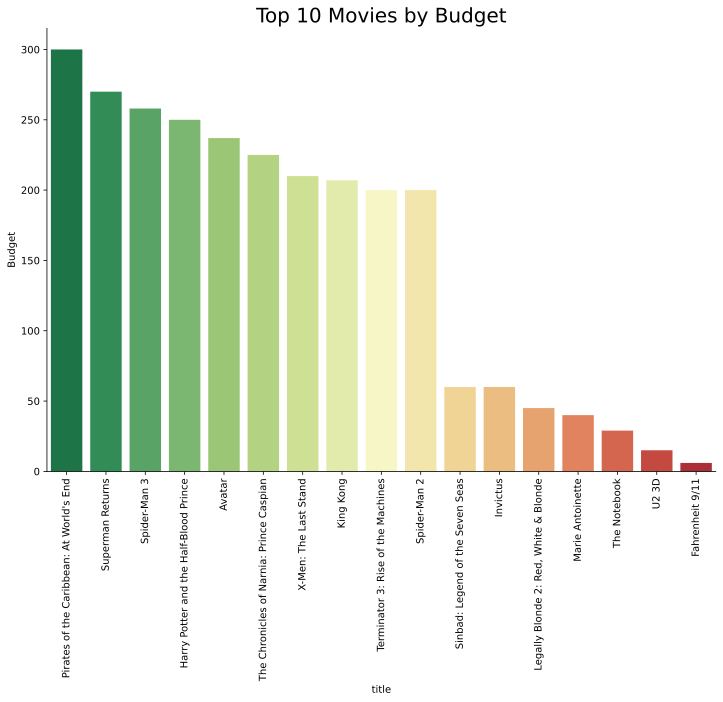

In [66]:
plt.figure(figsize = (12, 8))
sns.barplot(x = top_10_budget["title"] , y = top_10_budget["budget"] , hue = top_10_budget["title"] , legend = False , palette = "RdYlGn_r")
plt.title("Top 10 Movies by Budget", fontsize = 20)
plt.xlabel("title")
plt.ylabel("Budget")
plt.xticks(rotation = 90)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
plt.show()

4. Return the __10 most successful__ movies (in terms of revenue).

In [14]:
df["revenue"].nlargest(n = 10)

release_date
2009-12-10    2787.965087
2003-12-01    1118.888979
2006-06-20    1065.659812
2008-07-16    1004.558444
2001-11-16     976.475550
2007-05-19     961.000000
2003-05-30     940.335536
2007-06-28     938.212738
2009-07-07     933.959197
2002-12-18     926.287400
Name: revenue, dtype: float64

In [31]:
top_10_revenue = df.loc[df["revenue"].nlargest(n = 10).index , ["title" , "revenue"]].sort_values(by = "revenue" , ascending = False)
top_10_revenue

,title,revenue
release_date,,
2009-12-10,Avatar,2787.965087
2003-12-01,The Lord of the Rings: The Return of the King,1118.888979
2006-06-20,Pirates of the Caribbean: Dead Man's Chest,1065.659812
2008-07-16,The Dark Knight,1004.558444
2001-11-16,Harry Potter and the Philosopher's Stone,976.475550
2007-05-19,Pirates of the Caribbean: At World's End,961.000000
2003-05-30,Finding Nemo,940.335536
2007-06-28,Harry Potter and the Order of the Phoenix,938.212738
2009-07-07,Harry Potter and the Half-Blood Prince,933.959197


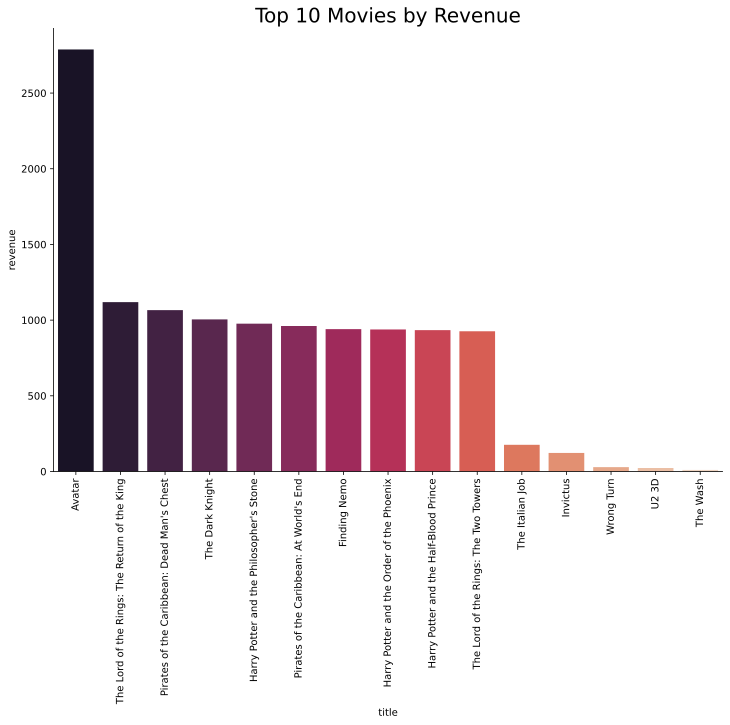

In [52]:
plt.figure(figsize = (12, 8))
sns.barplot(x = top_10_revenue["title"] , y = top_10_revenue["revenue"] , hue = top_10_revenue["title"] , legend = False , palette = "rocket")
plt.title("Top 10 Movies by Revenue", fontsize = 20)
plt.xlabel("title")
plt.ylabel("revenue")
plt.xticks(rotation = 90)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
plt.show()

5. Return the __Covariance Matrix__ between budget and revenue.

In [70]:
np.cov(df["budget"] , df["revenue"])

array([[ 1613.30000492,  4632.98056706],
       [ 4632.98056706, 26313.66274685]])

6. Calculate the __Covariance__ between budget and revenue.

In [71]:
df["budget"].cov(df["revenue"])

np.float64(4632.980567058417)

7. Calculate the __Correlation Matrix__ between budget and revenue.

In [72]:
np.corrcoef(df["budget"] , df["revenue"])

array([[1.        , 0.71106984],
       [0.71106984, 1.        ]])

8. Calculate the __Correlation__ between budget and revenue.

In [73]:
df["budget"].corr(df["revenue"])

np.float64(0.7110698407557395)

9. Calculate the __Correlation__ between budget and revenue using __covariance__ and the __variances/stds__ only.

In [74]:
corr = df["budget"].cov(df["revenue"]) / (df["budget"].std() * df["revenue"].std())
corr

np.float64(0.7110698407557389)

10. __Visualize__ the Relationship between budget and revenue. __Fill in the gaps__!

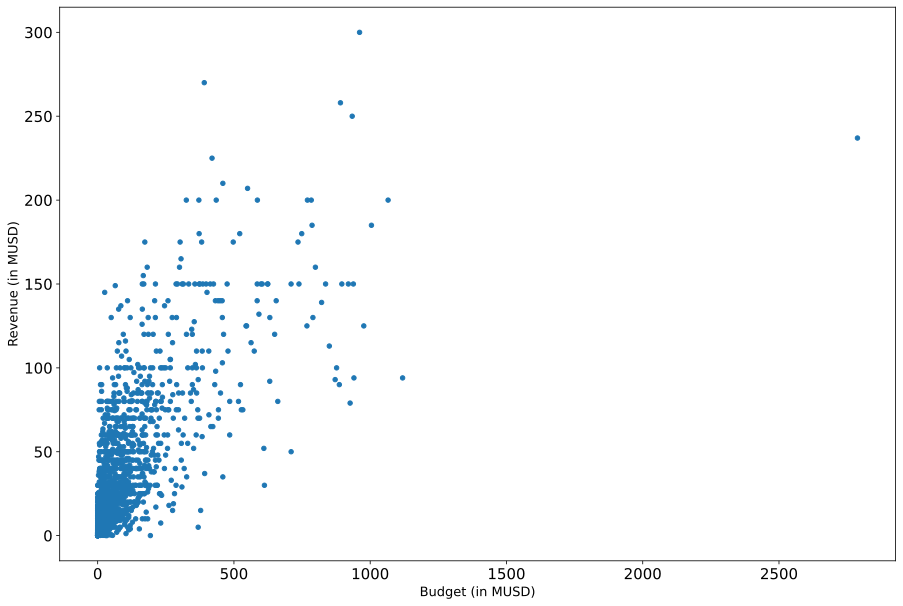

In [76]:
df.plot(kind = "scatter", x = "revenue", y = "budget", figsize = (15, 10), fontsize = 15)
plt.xlabel("Budget (in MUSD)", fontsize = 13)
plt.ylabel("Revenue (in MUSD)", fontsize = 13)
plt.show()

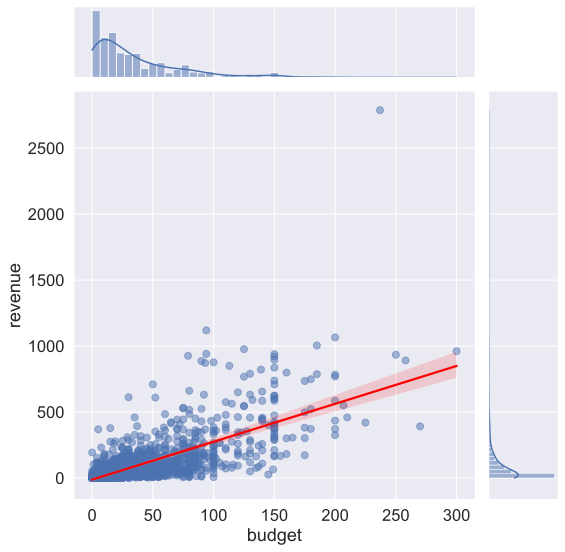

In [83]:
sns.set(font_scale=1.5)
sns.jointplot(data = df, x = "budget", y = "revenue", 
              height = 8 , 
              kind = "reg" , 
              ci = 95 , 
              scatter_kws = {"s" : 50 , "alpha" : 0.5} , 
             line_kws = {"color" : "red"}
)
sns.despine()

11. Calculate the __Correlation__ between budget and revenue (use __scipy.stats__) and __test on a 5% significance level__, whether there is a linear relationship (H0: r == 0). Calculate and use the __p-value__!

__H0: r == 0__ <br>
__Ha: r != 0__

In [84]:
#run the cell!
import scipy.stats as stats

In [85]:
r , p_value = stats.pearsonr(df.budget, df.revenue)
# r = correlation coefficient
# p_value = p-value

In [86]:
r

np.float64(0.7110698407557392)

In [87]:
p_value

np.float64(2.7838637675110197e-274)

In [88]:
print(f"Reject the Null Hypothesis at the 5% level of significance since the p_value is alomost 0.")

Reject the Null Hypothesis at the 5% level of significance since the p_value is alomost 0.


12. Create/Visualize a __simple Linear Regression Model__ with the __independent variable budget__ and one __independent variable revenue__ with seaborn. <br>
__Fill in the gaps!__

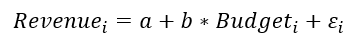

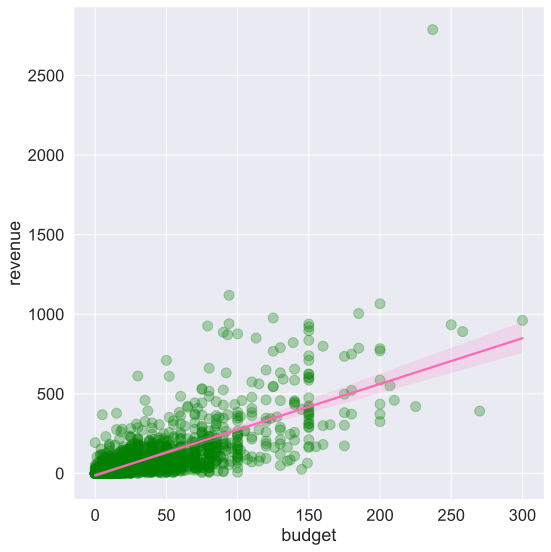

In [92]:
sns.set(font_scale=1.5)
sns.lmplot(data = df, x = "budget", y = "revenue", height = 8, ci = 95,
           scatter_kws = {"s": 100 , "color": "green" , "alpha": 0.3},
           line_kws = {"color": "hotpink"}
           )
plt.show()

13. Create a __simple Linear Regression Model__ with the __independent variable budget__ and one __independent variable revenue__ with __scipy__. Return and interpret the __Regression Coefficients__!

In [93]:
stats.linregress(x = df.budget, y = df.revenue)

LinregressResult(slope=np.float64(2.87174149440295), intercept=np.float64(-12.194862530953927), rvalue=np.float64(0.7110698407557394), pvalue=np.float64(2.7838637675098956e-274), stderr=np.float64(0.0673437836115018), intercept_stderr=np.float64(3.6860102284074068))

14. Calculate the __Slope Coefficient__ using __Covariance and Variance(s)__ only.

In [94]:
df["budget"].cov(df["revenue"])/ df["budget"].var()

np.float64(2.871741494402949)

------------------------------------------------------------------------------------------

In the following you are going to create the Market Model (__Single Factor Model__) for __Walmart__ (WMT) using daily price data from  __Jan-01-2000__ until __Dec-31-2009__. Use the __SP500 Total Return Index__ ("^SP500TR") as Proxy for the __Market Portfolio__.

In [95]:
#run the cell!
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

15. Get the __Data__. __Fill in the gaps!__

In [97]:
df = yf.download(["WMT", "^SP500TR"], start = "1999-12-31", end = "2009-12-31" , multi_level_index = False , auto_adjust = True)
df = df["Close"]
df

[*********************100%***********************]  2 of 2 completed


Ticker,WMT,^SP500TR
Date,,
1999-12-31,14.644452,2021.400024
2000-01-03,14.154541,2002.109985
2000-01-04,13.624907,1925.410034
2000-01-05,13.346840,1929.280029
2000-01-06,13.492499,1931.510010
...,...,...
2009-12-23,12.692565,1845.800049
2009-12-24,12.759219,1855.500000
2009-12-28,12.849679,1857.890015


16. Create a Dataframe with __daily returns__.

In [99]:
ret = df.pct_change().dropna()
ret

Ticker,WMT,^SP500TR
Date,,
2000-01-03,-0.033454,-0.009543
2000-01-04,-0.037418,-0.038310
2000-01-05,-0.020409,0.002010
2000-01-06,0.010913,0.001156
2000-01-07,0.075564,0.027088
...,...,...
2009-12-23,-0.000375,0.002515
2009-12-24,0.005251,0.005255
2009-12-28,0.007090,0.001288


17. Create/Visualize the __simple Linear Regression Model__  with seaborn. <br>
__Fill in the gaps!__

In [110]:
wmt_beta =ret["WMT"].cov(ret["^SP500TR"])/ret["^SP500TR"].var()
wmt_beta

np.float64(0.7018178127156091)

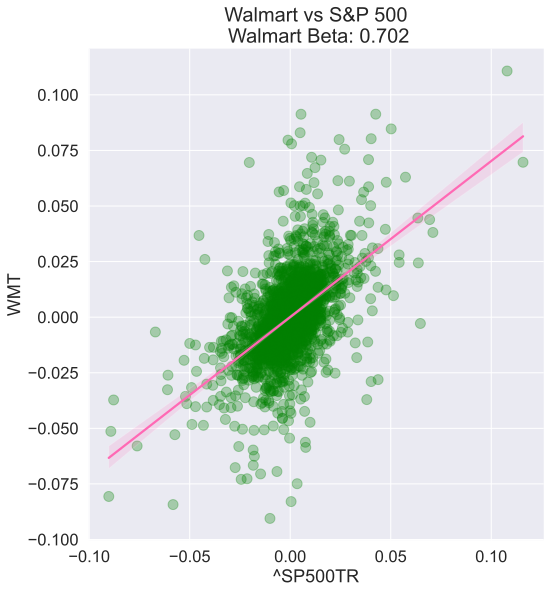

In [111]:
sns.set(font_scale=1.5)
sns.lmplot(data = ret, x = "^SP500TR", y = "WMT", height = 8, ci = 95 , 
           scatter_kws = {"s": 100 , "color": "green" , "alpha": 0.3},
           line_kws = {"color": "hotpink"}
           )
plt.title(f" Walmart vs S&P 500 \n Walmart Beta: {wmt_beta:.3f}", fontsize = 20)
plt.show()

18. Create the __simple Linear Regression Model__ with __scipy__. Return and interpret the __Regression Coefficients__!

In [112]:
beta , intercept , rvalue , pvalue , stderr = stats.linregress(x = ret["^SP500TR"], y = ret.WMT)

In [113]:
beta
# beta is the beta derived with CAPM . so if beta < 1 then the stock is less volatile than the market
# and if beta > 1 then the stock is more volatile than the market
# if beta = 1 then the stock is as volatile as the market

np.float64(0.7018178127156092)

In [116]:
intercept
# intercept is the y-intercept

np.float64(6.581558227679782e-05)

In [115]:
rvalue
# rvalue is the correlation coefficient


np.float64(0.5476934538294159)

In [117]:
pvalue

np.float64(8.529584585066134e-197)

# Well Done!